In [20]:
import numpy as np
import pandas as pd
# import optuna
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv(r'../datasets/train.csv')
y = df['TARGET']
df = df.drop(columns=['TARGET', 'ID'])

In [90]:
df['APP_COMP_TYPE'].unique()

<StringArray>
[nan, 'PRIVATE', 'STATE', 'IP', 'INTER']
Length: 5, dtype: str

# Общая информация

В датасете 355190 уникальных записей клиентов и 113 фичей

Датасет содержит:
- информацию о клиентах, которые ушли в течение 3х месяцев – столбец называется 'TARGET'
- информацию о услугах, которыми пользовался клиент: 
    - Подключена ли телефонная связь (PhoneService)
    - Использует ли клиент несколько телефонных линий (MultipleLines)
    - Тип интернет-подключения клиента(InternetService)
    - Подключена ли услуга интернет-безопасности (OnlineSecurity)
    - Подключено ли облачное резервное копирование данных (OnlineBackup) 
    - Подключена ли услуга гарантии на устройства (DeviceProtection)
    - Подключена ли техническая поддержка (TechSupport)
    - Подключено ли телевидение (StreamingTV)
    - Подключены ли фильмы (StreamingMovies)
- информацию о договоре с клиентом
    - Продолжительность обслуживания клиента (в месяцах) (tenure)
    - Тип договора с клиентом (Contract)
    - Способ оплаты (PaymentMethod)
    - Электронные счета (PaperlessBilling)
    - Ежемесячная стоимость услуг (MonthlyCharges)
    - Общая сумма платежей (TotalCharges)
- общую информацию о клиентах 
    - возраст в месяцах (AGE) 
    - наличие машины (APP_CAR)
    - тип работадателя (APP_COMP_TYPE)
    - наличие водительских прав (APP_DRIVING_LICENSE)


In [3]:
df.describe()

,ID,CR_PROD_CNT_IL,AMOUNT_RUB_CLO_PRC,PRC_ACCEPTS_A_EMAIL_LINK,APP_REGISTR_RGN_CODE,PRC_ACCEPTS_A_POS,PRC_ACCEPTS_A_TK,TURNOVER_DYNAMIC_IL_1M,CNT_TRAN_AUT_TENDENCY1M,SUM_TRAN_AUT_TENDENCY1M,...,LDEAL_ACT_DAYS_ACC_PCT_AVG,REST_DYNAMIC_CC_3M,MED_DEBT_PRC_YWZ,LDEAL_ACT_DAYS_PCT_TR3,LDEAL_ACT_DAYS_PCT_AAVG,LDEAL_DELINQ_PER_MAXYWZ,TURNOVER_DYNAMIC_CC_3M,LDEAL_ACT_DAYS_PCT_TR,LDEAL_ACT_DAYS_PCT_TR4,LDEAL_ACT_DAYS_PCT_CURR
count,355190.000000,355190.000000,316867.000000,155163.0,60550.000000,155163.0,155163.0,355190.000000,77112.000000,77112.000000,...,93448.000000,355190.000000,95713.000000,93448.000000,98175.000000,95713.000000,355190.000000,93448.000000,93448.000000,93448.000000
mean,368794.674875,0.105225,0.044045,0.0,50.947498,0.0,0.0,0.001305,0.416896,0.414572,...,0.051419,0.007309,0.055074,0.025707,0.049943,0.009252,0.004309,0.013938,0.013938,0.013938
std,128148.804566,0.431372,0.108449,0.0,21.777855,0.0,0.0,0.029118,0.316493,0.338612,...,0.134960,0.066681,0.215909,0.115732,0.185830,0.092789,0.059852,0.097099,0.097099,0.097099
min,146841.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.006944,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,257846.250000,0.000000,0.000000,0.0,33.000000,0.0,0.0,0.000000,0.166667,0.139645,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,368778.500000,0.000000,0.000000,0.0,54.000000,0.0,0.0,0.000000,0.300000,0.285714,...,0.008822,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,479737.750000,0.000000,0.036608,0.0,72.000000,0.0,0.0,0.000000,0.571429,0.661195,...,0.033563,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,590828.000000,11.000000,1.000000,0.0,89.000000,0.0,0.0,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 355190 entries, 0 to 355189
Columns: 114 entries, CR_PROD_CNT_IL to LDEAL_ACT_DAYS_PCT_CURR
dtypes: float64(94), int64(7), str(13)
memory usage: 308.9 MB


In [11]:
cat_cols = df.select_dtypes(['string']).columns.to_list()
fl_cols = df.select_dtypes(['float']).columns.to_list()
int_cols = df.select_dtypes(['int']).columns.to_list()

# int cols

## распределения по количеству используемых продуктов из разных категорий

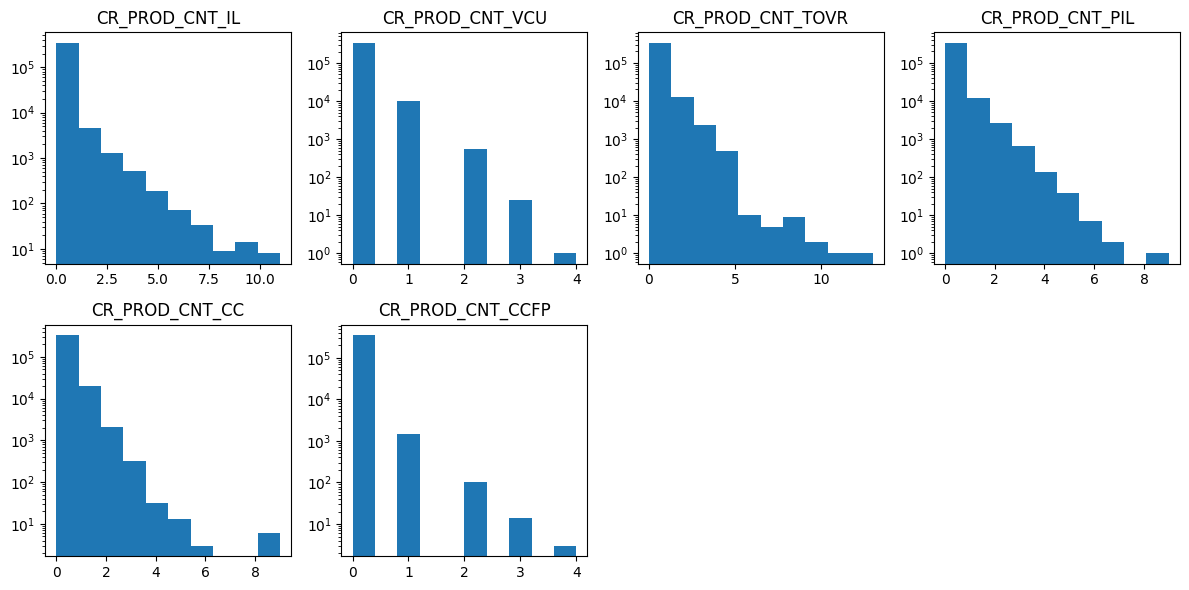

In [74]:
prod_cnt_cols = [i for i in int_cols if i.startswith('CR_')]
fig = plt.figure(figsize=(12,6))
for en, i in enumerate(prod_cnt_cols):
    ax = fig.add_subplot(2, 4, en+1)
    ax.hist(x=df[i], log=True)
    ax.set_title(i)
plt.tight_layout()
plt.show()

In [73]:
for en, i in enumerate(prod_cnt_cols):
    print(df[i].unique())

[ 0  2  4  1  3  5  6  7 10  9  8 11]
[0 1 2 3 4]
[ 0  2  1  3  4  5  6  8 11 10  9  7 13]
[0 1 2 3 4 5 6 7 9]
[0 1 3 2 4 5 9 6]
[0 1 2 3 4]


## распределение по возрасту пользователей

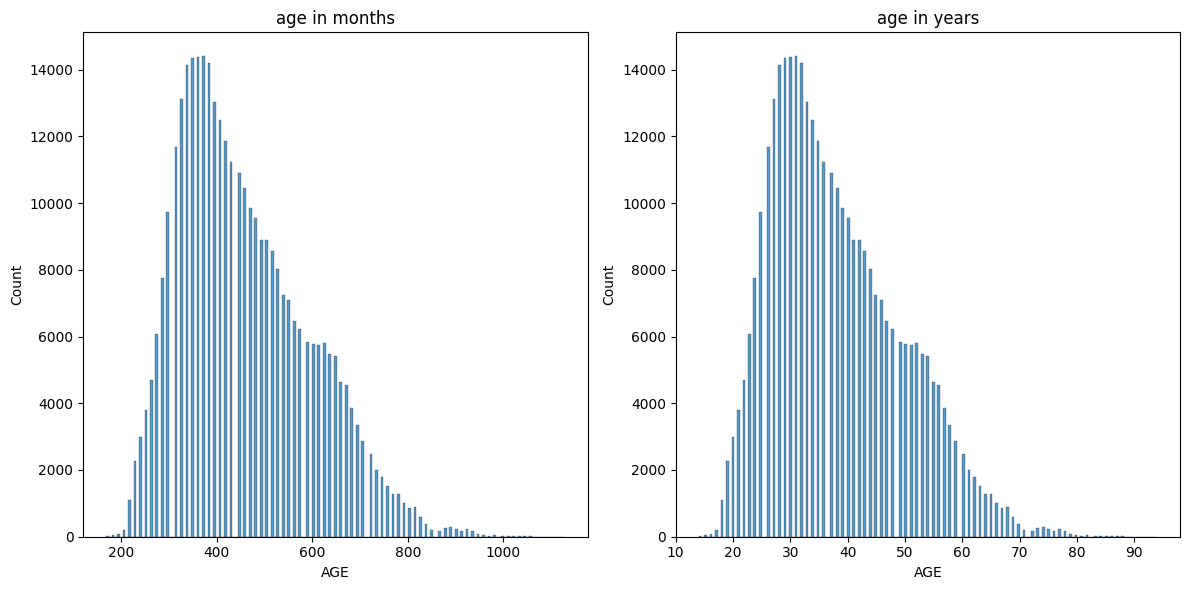

In [82]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,6))
sns.histplot(df, x='AGE', ax=ax[0])
ax[0].set_title('age in months')

sns.histplot(x=df['AGE']//12, ax=ax[1])
ax[1].set_title('age in years')

plt.tight_layout()
plt.show()

In [85]:
df['AGE']

0         660
1         552
2         420
3         372
4         288
         ... 
355185    516
355186    672
355187    372
355188    540
355189    672
Name: AGE, Length: 355190, dtype: int64

In [35]:
y

0         0
1         0
2         0
3         0
4         0
         ..
355185    0
355186    0
355187    0
355188    0
355189    1
Name: TARGET, Length: 355190, dtype: int64

In [54]:
cols = ['AMOUNT_RUB_CLO_PRC', 'AMOUNT_RUB_SUP_PRC', 'AMOUNT_RUB_NAS_PRC', 'AMOUNT_RUB_ATM_PRC']
# y[df[cols].isna()]

In [60]:
dff = df[cols].sum(axis=1)
dff[dff>1]

13        1.0
163       1.0
204       1.0
225       1.0
255       1.0
         ... 
354657    1.0
354696    1.0
354697    1.0
354973    1.0
355184    1.0
Length: 3885, dtype: float64

In [47]:
y[df[cols[0]].isna()].value_counts()/38323

TARGET
0    0.936539
1    0.063461
Name: count, dtype: float64

<Axes: xlabel='AGE', ylabel='Count'>

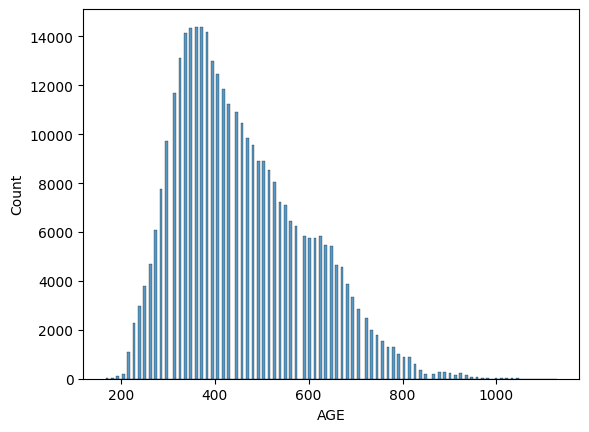